Projeto de detecção de fraudes em transações de cartão de credito



In [1]:
import pandas as pd
import numpy as np

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.shape

(284807, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [5]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


**Tratamento de dados**

---




In [6]:
df["Amount_log"] = np.log1p(df["Amount"])

Padronização

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

Separações de treino

In [8]:
from sklearn.model_selection import train_test_split

df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

X = df.drop(["Class", "Time", "Amount", "Amount_log"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**Logistic Regression**

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



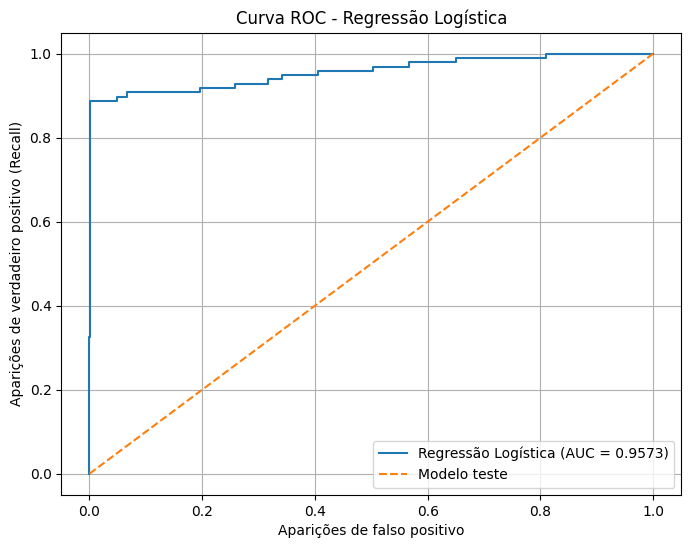

AUC: 0.9572835078037969


In [25]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades previstas pela Regressão Logística
y_probs = model.predict_proba(X_test)[:, 1]

# Calcular os pontos da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calcular AUC
auc = roc_auc_score(y_test, y_probs)

# Plotar a curva
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Regressão Logística (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Modelo teste"
)

plt.title("Curva ROC - Regressão Logística")
plt.xlabel("Aparições de falso positivo")
plt.ylabel("Aparições de verdadeiro positivo (Recall)")
plt.legend()
plt.grid()
plt.show()

print("AUC:", auc)

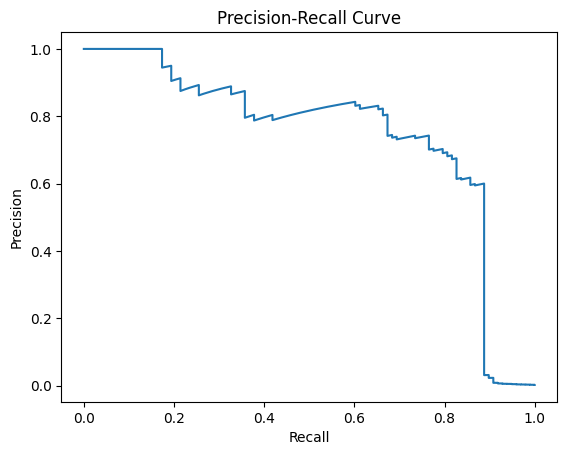

In [16]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Calcula os pontos da curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


**`Balanceamento de dados`**


In [17]:
# Under Sampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy=0.5,
    random_state=42
)

X_train_under, y_train_under = rus.fit_resample(
    X_train,
    y_train
)

print("Antes:")
print(y_train.value_counts())

print("\nDepois:")
print(y_train_under.value_counts())

Antes:
Class
0    227451
1       394
Name: count, dtype: int64

Depois:
Class
0    788
1    394
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

#SMOTE
scaler_smote = StandardScaler()

X_train_scaled = scaler_smote.fit_transform(X_train)
X_test_scaled = scaler_smote.transform(X_test)

# Aplicar SMOTE somente no treinamento
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Antes:")
print(y_train.value_counts())

print("\nDepois:")
print(y_train_smote.value_counts())

Antes:
Class
0    227451
1       394
Name: count, dtype: int64

Depois:
Class
0    227451
1    113725
Name: count, dtype: int64


Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



BASELINE

In [20]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [21]:
treshold = 0.5

y_pred_custom = (y_probs > treshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



XGBoost

In [23]:
from xgboost import XGBClassifier
#Calibações
xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric="logloss"
)
#ordenação
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:38:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Importância das variáveis

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Extrair a importância das variáveis do Random Forest
importancias = rf.feature_importances_

# Criar uma tabela com os nomes das variáveis
df_importancia = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": importancias
})

# Ordenar da mais importante para a menos importante
df_importancia = df_importancia.sort_values(
    by="Importancia",
    ascending=False
)

# Mostrar as 15 variáveis mais importantes
display(df_importancia.head(15))

,Variavel,Importancia
13,V14,0.219582
9,V10,0.123319
3,V4,0.104623
16,V17,0.089758
11,V12,0.072306
10,V11,0.070334
2,V3,0.062020
15,V16,0.042267
6,V7,0.031850
1,V2,0.029640


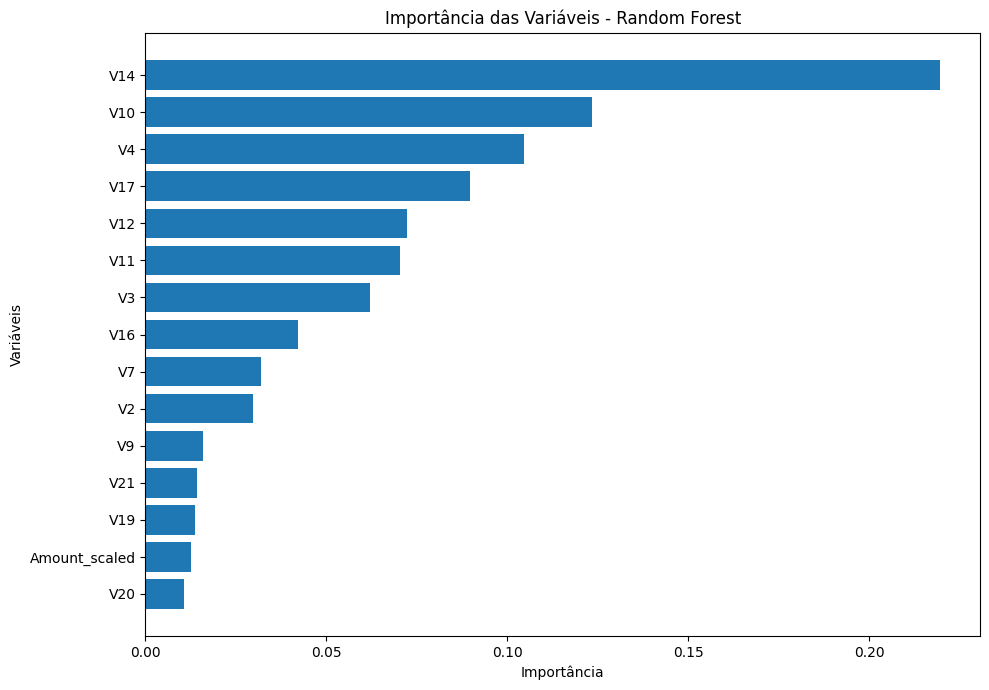

In [28]:
# Selecionar as 15 variáveis mais importantes
top_15 = df_importancia.head(15).sort_values(
    by="Importancia",
    ascending=True
)

# Criar o gráfico
plt.figure(figsize=(10, 7))

plt.barh(
    top_15["Variavel"],
    top_15["Importancia"]
)

plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.title("Importância das Variáveis - Random Forest")

plt.tight_layout()
plt.show()

SHAP

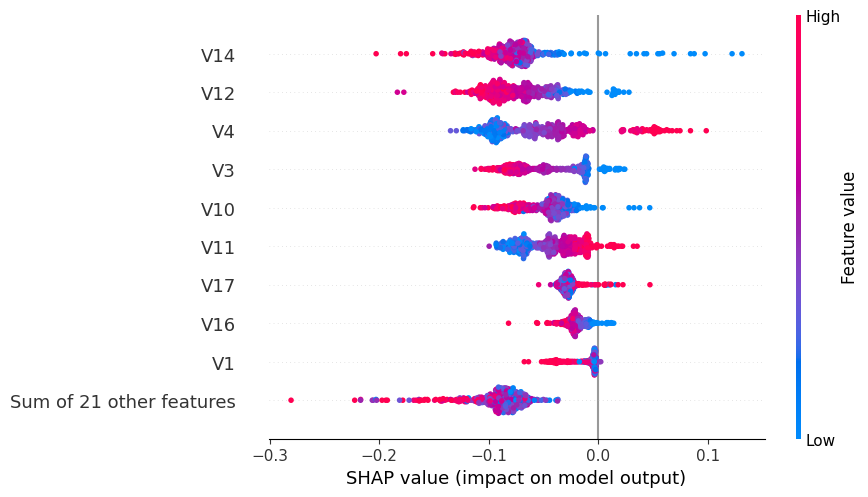

In [29]:
import shap

explainer = shap.TreeExplainer(rf)

# Usar uma amostra para reduzir o consumo de memória
X_shap = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

shap_values = explainer(X_shap)

shap.plots.beeswarm(shap_values[:, :, 1])